In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/DatasetMeasles/cleaned_data.csv")

Load Dataset

In [3]:
df

,Country,Year,Population,Reported_measles_cases,Suspected_measles_cases,Measles_deaths,MCV1_coverage (%),MCV2_coverage (%),DTP3_coverage (%),Population_density (people/km²),...,Internet_penetration (%),Routine_immunization_dropout (%),Outbreak_Label,Avg_Annual_Temperature,Total_Annual_Rainfall,Avg_Annual_Humidity,Rainy_Season_Length,Temp_Seasonality,Dry_Season_Length,Extreme_Rain_Days
0,Argentina,1990,32000000,8000.0,4300.0,150.0,75.0,90.0,80.0,15.0,...,3.0,15.0,TRUE,26.0,1190.0,73.5,7.0,2.1,5.0,34.0
1,Argentina,2006,39200000,500.0,4300.0,10.0,95.0,90.0,95.0,16.0,...,45.0,4.0,TRUE,26.0,1190.0,73.5,7.0,2.1,5.0,34.0
2,Argentina,2018,44400000,3000.0,4300.0,40.0,90.0,86.0,92.0,16.0,...,82.0,8.0,FALSE,26.0,1190.0,73.5,7.0,2.1,5.0,34.0
3,Argentina,2020,45200000,400.0,4300.0,5.0,95.0,92.0,95.0,17.0,...,85.0,2.0,TRUE,26.0,1190.0,73.5,7.0,2.1,5.0,34.0
4,Australia,1990,17200000,2300.0,2800.0,5.0,87.0,70.0,90.0,2.3,...,25.0,6.0,Outbreak,26.0,1190.0,73.5,7.0,2.1,5.0,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,Vietnam,2020,97300000,400.0,4300.0,5.0,97.0,90.0,96.0,300.0,...,70.0,3.0,TRUE,26.0,1190.0,73.5,7.0,2.1,5.0,34.0
156,Yemen,1995,15000000,9800.0,11200.0,420.0,52.0,18.0,56.0,27.0,...,1.0,18.0,Outbreak,26.0,1190.0,73.5,7.0,2.1,5.0,34.0
157,Yemen,2005,20500000,5500.0,6000.0,230.0,63.0,35.0,70.0,32.0,...,2.0,14.0,Non-outbreak,26.0,1190.0,73.5,7.0,2.1,5.0,34.0
158,Yemen,2015,27000000,13200.0,15000.0,590.0,72.0,45.0,76.0,38.0,...,3.0,16.0,Outbreak,26.0,1190.0,73.5,7.0,2.1,5.0,34.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 33 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 160 non-null    object 
 1   Year                                    160 non-null    int64  
 2   Population                              160 non-null    int64  
 3   Reported_measles_cases                  160 non-null    float64
 4   Suspected_measles_cases                 160 non-null    float64
 5   Measles_deaths                          160 non-null    float64
 6   MCV1_coverage (%)                       160 non-null    float64
 7   MCV2_coverage (%)                       160 non-null    float64
 8   DTP3_coverage (%)                       160 non-null    float64
 9   Population_density (people/km²)         160 non-null    float64
 10  Urbanization (%)                        160 non-null    float6

In [5]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index()
      .rename(columns={'index': 'Column', 0: 'Missing_Count'})
)
missing_summary['Missing_%'] = (missing_summary['Missing_Count'] / len(df)) * 100
missing_summary = missing_summary.sort_values(by='Missing_%', ascending=False)

In [6]:
missing_summary

,Column,Missing_Count,Missing_%
0,Country,0,0.0
1,Year,0,0.0
2,Population,0,0.0
3,Reported_measles_cases,0,0.0
4,Suspected_measles_cases,0,0.0
5,Measles_deaths,0,0.0
6,MCV1_coverage (%),0,0.0
7,MCV2_coverage (%),0,0.0
8,DTP3_coverage (%),0,0.0
9,Population_density (people/km²),0,0.0


Correllation Matrix

In [7]:
corr = df.corr(numeric_only=True)

In [8]:
corr

,Year,Population,Reported_measles_cases,Suspected_measles_cases,Measles_deaths,MCV1_coverage (%),MCV2_coverage (%),DTP3_coverage (%),Population_density (people/km²),Urbanization (%),...,Air_travel_volume (million passengers),Internet_penetration (%),Routine_immunization_dropout (%),Avg_Annual_Temperature,Total_Annual_Rainfall,Avg_Annual_Humidity,Rainy_Season_Length,Temp_Seasonality,Dry_Season_Length,Extreme_Rain_Days
Year,1.000000,0.130152,0.030190,-0.178389,-0.328725,0.430351,0.315482,0.335662,0.077855,0.158545,...,0.250454,0.552030,-0.394370,0.021949,0.037626,0.076589,0.121764,-0.015587,-0.121764,0.106611
Population,0.130152,1.000000,0.082112,0.227026,0.209317,-0.048362,-0.033980,-0.119292,0.378585,0.016758,...,0.404025,0.150254,0.132981,-0.095112,0.205642,0.124761,0.126999,0.090245,-0.126999,0.143451
Reported_measles_cases,0.030190,0.082112,1.000000,0.044184,0.032887,-0.435582,0.000355,-0.468942,-0.039952,-0.132586,...,-0.109916,-0.146365,0.048022,0.046165,0.147500,0.247763,0.253558,-0.155590,-0.253558,0.256193
Suspected_measles_cases,-0.178389,0.227026,0.044184,1.000000,0.832585,-0.370639,-0.472217,-0.391662,0.099919,-0.164056,...,-0.118059,-0.153082,0.511950,0.090144,0.026392,-0.002778,0.041433,-0.071336,-0.041433,-0.019182
Measles_deaths,-0.328725,0.209317,0.032887,0.832585,1.000000,-0.567617,-0.541221,-0.570654,0.053533,-0.253659,...,-0.165554,-0.262757,0.679675,0.082551,0.035984,0.002681,0.042130,-0.074786,-0.042130,-0.022213
MCV1_coverage (%),0.430351,-0.048362,-0.435582,-0.370639,-0.567617,1.000000,0.701752,0.952300,0.055201,0.426508,...,0.393747,0.526822,-0.758761,-0.101323,-0.129617,-0.129186,-0.141142,0.153851,0.141142,-0.149453
MCV2_coverage (%),0.315482,-0.033980,0.000355,-0.472217,-0.541221,0.701752,1.000000,0.733409,0.005371,0.487977,...,0.405920,0.478238,-0.647670,-0.168788,-0.214551,-0.146556,-0.168892,0.209864,0.168892,-0.149678
DTP3_coverage (%),0.335662,-0.119292,-0.468942,-0.391662,-0.570654,0.952300,0.733409,1.000000,0.066918,0.445309,...,0.366403,0.480806,-0.709613,-0.112813,-0.159403,-0.127618,-0.161969,0.148586,0.161969,-0.189361
Population_density (people/km²),0.077855,0.378585,-0.039952,0.099919,0.053533,0.055201,0.005371,0.066918,1.000000,-0.144194,...,0.053456,0.074143,-0.029069,0.003778,0.080688,0.051716,0.042471,0.051353,-0.042471,0.014313
Urbanization (%),0.158545,0.016758,-0.132586,-0.164056,-0.253659,0.426508,0.487977,0.445309,-0.144194,1.000000,...,0.606691,0.533078,-0.370958,-0.191637,0.025841,0.158448,0.088409,0.158933,-0.088409,0.026670


In [9]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

GEOGRAPHIC TRENDS

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


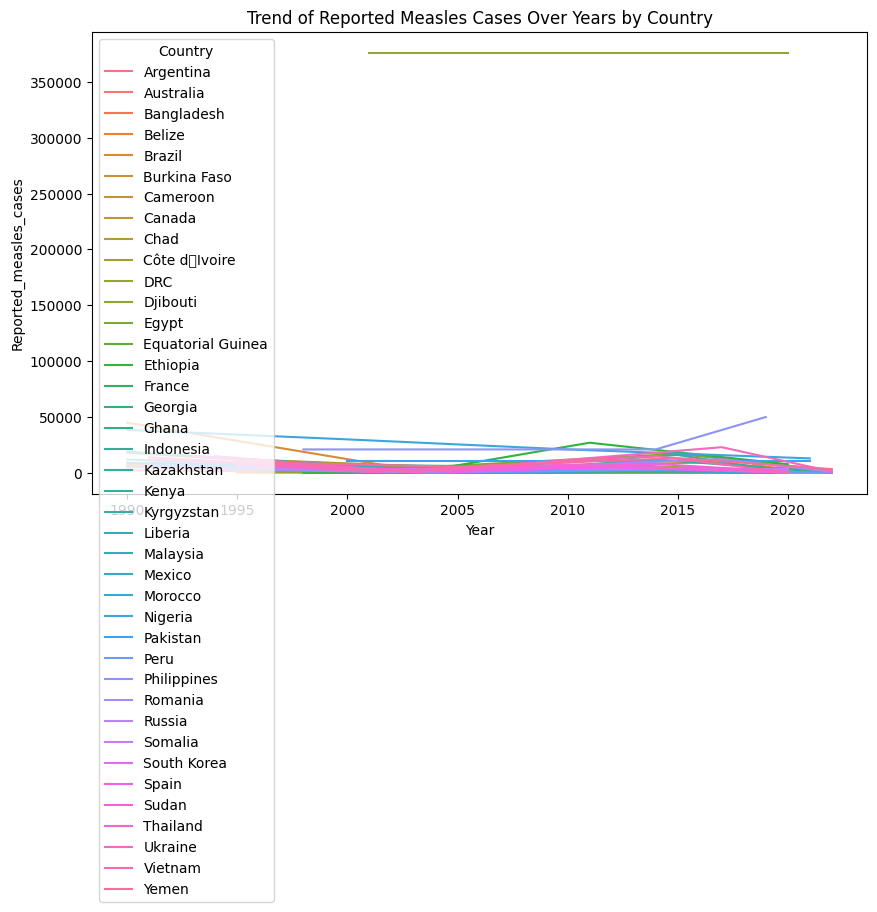

In [11]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='Reported_measles_cases', hue='Country')
plt.title('Trend of Reported Measles Cases Over Years by Country')
plt.show()

FEATURE INTERACTIONS

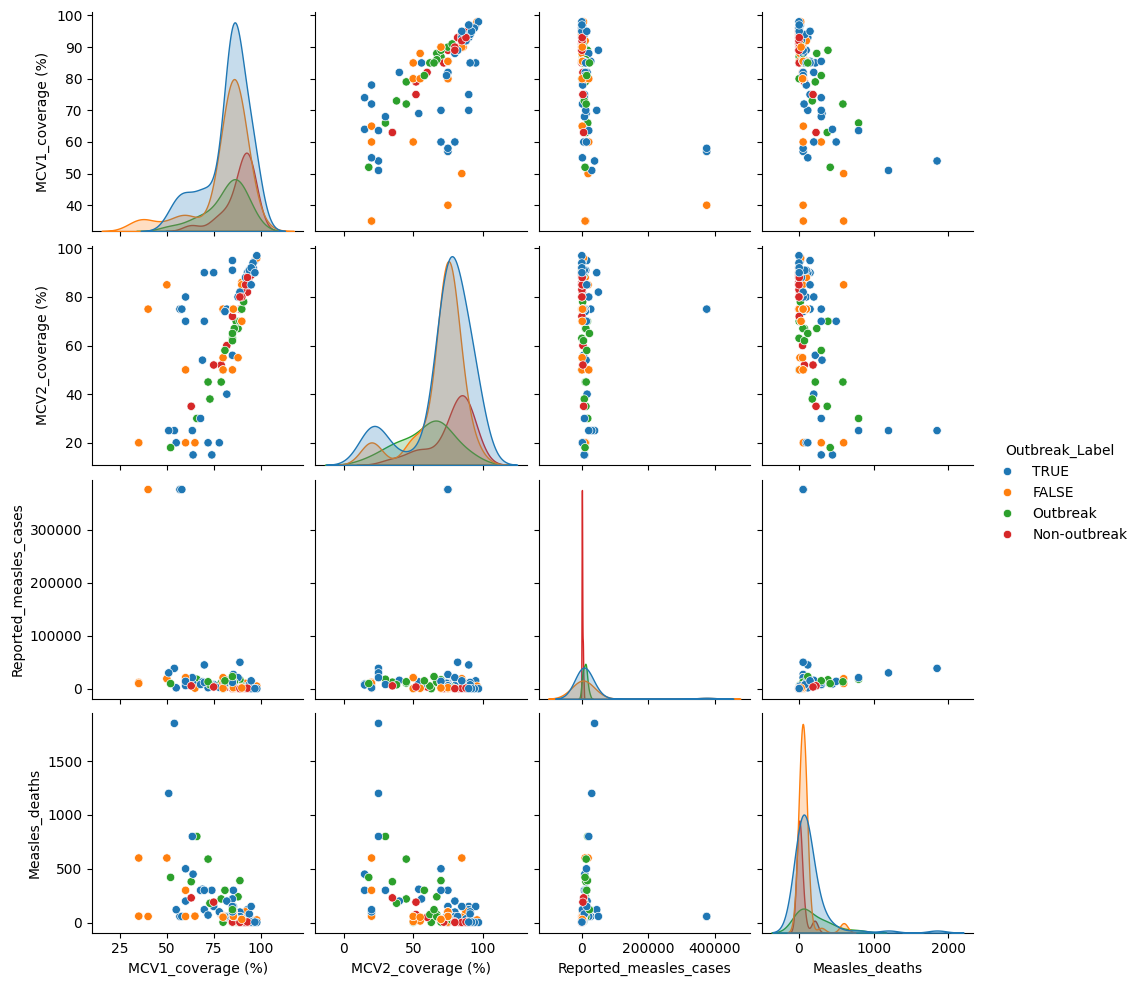

In [12]:
sns.pairplot(df, vars=['MCV1_coverage (%)', 'MCV2_coverage (%)',
                       'Reported_measles_cases', 'Measles_deaths'],
             hue='Outbreak_Label', diag_kind='kde')
plt.show()

In [13]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df.select_dtypes(include=['float64'])))
outliers = (z_scores > 3).sum(axis=0)
pd.DataFrame({'Column': df.select_dtypes(include=['float64']).columns,
              'Outlier_Count': outliers})


,Column,Outlier_Count
0,Reported_measles_cases,4
1,Suspected_measles_cases,4
2,Measles_deaths,4
3,MCV1_coverage (%),3
4,MCV2_coverage (%),0
5,DTP3_coverage (%),3
6,Population_density (people/km²),4
7,Urbanization (%),0
8,"Birth_rate (per 1,000)",0
9,Proportion_under5 (%),0


HANDLE OUTLIERS

In [14]:
from scipy.stats.mstats import winsorize
df['GDP_per_capita (US$)'] = winsorize(df['GDP_per_capita (US$)'], limits=[0.05, 0.05])


In [16]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

NameError: name 'col' is not defined

In [17]:
df['GDP_per_capita (US$)'] = np.log1p(df['GDP_per_capita (US$)'])


<Axes: xlabel='GDP_per_capita (US$)', ylabel='Measles_deaths'>

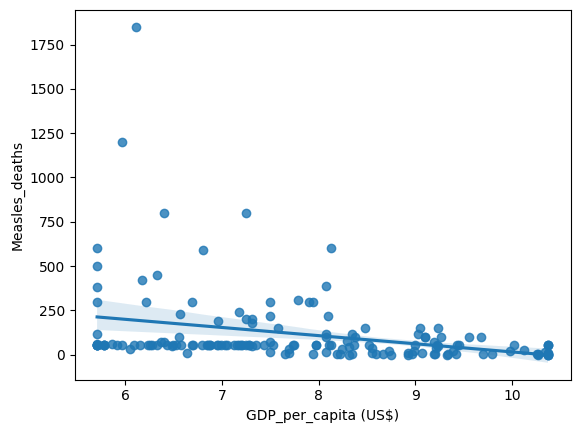

In [ ]:
sns.regplot(x='GDP_per_capita (US$)', y='Measles_deaths', data=df)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 33 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 160 non-null    object 
 1   Year                                    160 non-null    int64  
 2   Population                              160 non-null    int64  
 3   Reported_measles_cases                  160 non-null    float64
 4   Suspected_measles_cases                 160 non-null    float64
 5   Measles_deaths                          160 non-null    float64
 6   MCV1_coverage (%)                       160 non-null    float64
 7   MCV2_coverage (%)                       160 non-null    float64
 8   DTP3_coverage (%)                       160 non-null    float64
 9   Population_density (people/km²)         160 non-null    float64
 10  Urbanization (%)                        160 non-null    float6

In [19]:
# df = df.drop('Outbreak_alert', axis=1)
df = df.drop('Country', axis=1)
df = df.drop('Year', axis=1)


In [20]:
df['Outbreak_Label'].unique()

array(['TRUE', 'FALSE', 'Outbreak', 'Non-outbreak'], dtype=object)

In [21]:
mapping = {
    'TRUE': 1,
    'Outbreak': 1,
    'FALSE': 0,
    'Non-outbreak': 0
}

In [22]:
df['Outbreak_Label'] = df['Outbreak_Label'].map(mapping)

Modelling

In [26]:
from sklearn.preprocessing import LabelEncoder


y = df['Outbreak_Label']


categorical_cols = ['SIAs_in_past_3yrs']


le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


X = df.drop(columns=['Outbreak_Label','Outbreak_alert'])


X = X.apply(pd.to_numeric, errors='coerce').astype(np.float32)

print(X.dtypes)
print("\nAny NaN left? ", X.isna().sum().sum())


Population                                float32
Reported_measles_cases                    float32
Suspected_measles_cases                   float32
Measles_deaths                            float32
MCV1_coverage (%)                         float32
MCV2_coverage (%)                         float32
DTP3_coverage (%)                         float32
Population_density (people/km²)           float32
Urbanization (%)                          float32
Birth_rate (per 1,000)                    float32
Proportion_under5 (%)                     float32
GDP_per_capita (US$)                      float32
Health_expenditure_per_capita (US$)       float32
Hospital_beds_per_1000                    float32
Physicians_per_10000                      float32
GoogleTrends_index                        float32
Dropout_rate (MCV1?MCV2)                  float32
Measles_incidence_rate (per million)      float32
SIAs_in_past_3yrs                         float32
Air_travel_volume (million passengers)    float32


**FEature Engineering**

In [27]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Drop Country column
X = df.drop(columns=['Outbreak_Label','Outbreak_alert'])
y = df['Outbreak_Label']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === RFE (Recursive Feature Elimination) ===
model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_scaled, y)

selected_features_rfe = X.columns[rfe.support_]
print("Selected Features by RFE:")
print(selected_features_rfe.tolist(), "\n")

# === PCA (Principal Component Analysis) ===
pca = PCA(n_components=5)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

# Extract top contributing features for each principal component
loading_scores = pd.DataFrame(pca.components_.T,
                              columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                              index=X.columns)

top_features_per_pc = {}
for i in range(pca.n_components_):
    sorted_features = loading_scores.iloc[:, i].abs().sort_values(ascending=False).head(5)
    top_features_per_pc[f'PC{i+1}'] = sorted_features.index.tolist()

print("Top Contributing Features per PCA Component:")
for pc, feats in top_features_per_pc.items():
    print(f"{pc}: {feats}")
print()

# ===  MI (Mutual Information) ===
mi_scores = mutual_info_classif(X_scaled, y)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

top_mi_features = mi_df.head(21)
print("Top 10 Features by Mutual Information:")
print(top_mi_features, "\n")


Selected Features by RFE:
['Suspected_measles_cases', 'Measles_deaths', 'MCV1_coverage (%)', 'Proportion_under5 (%)', 'GoogleTrends_index', 'Measles_incidence_rate (per million)', 'Routine_immunization_dropout (%)', 'Avg_Annual_Humidity', 'Rainy_Season_Length', 'Extreme_Rain_Days'] 

Top Contributing Features per PCA Component:
PC1: ['Proportion_under5 (%)', 'GDP_per_capita (US$)', 'DTP3_coverage (%)', 'Birth_rate (per 1,000)', 'MCV1_coverage (%)']
PC2: ['Rainy_Season_Length', 'Dry_Season_Length', 'Total_Annual_Rainfall', 'Avg_Annual_Humidity', 'Extreme_Rain_Days']
PC3: ['Suspected_measles_cases', 'Measles_deaths', 'Hospital_beds_per_1000', 'Population', 'Physicians_per_10000']
PC4: ['Measles_incidence_rate (per million)', 'Reported_measles_cases', 'Avg_Annual_Temperature', 'Temp_Seasonality', 'SIAs_in_past_3yrs']
PC5: ['Population_density (people/km²)', 'Population', 'Health_expenditure_per_capita (US$)', 'Avg_Annual_Temperature', 'Temp_Seasonality']

Top 10 Features by Mutual Informa

In [28]:
X[selected_features_rfe].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Suspected_measles_cases               160 non-null    float64
 1   Measles_deaths                        160 non-null    float64
 2   MCV1_coverage (%)                     160 non-null    float64
 3   Proportion_under5 (%)                 160 non-null    float64
 4   GoogleTrends_index                    160 non-null    float64
 5   Measles_incidence_rate (per million)  160 non-null    float64
 6   Routine_immunization_dropout (%)      160 non-null    float64
 7   Avg_Annual_Humidity                   160 non-null    float64
 8   Rainy_Season_Length                   160 non-null    float64
 9   Extreme_Rain_Days                     160 non-null    float64
dtypes: float64(10)
memory usage: 12.6 KB


In [29]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['Outbreak_Label'])


DEEP LEARNING MODEL

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, GRU, Dense
from tensorflow.keras.optimizers import Adam

In [31]:
# --- Split helper ---
def prepare_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    # reshape for LSTM input: [samples, timesteps, features]
    X_train = np.expand_dims(X_train, axis=1)
    X_test = np.expand_dims(X_test, axis=1)
    return X_train, X_test, y_train, y_test

# --- Model builders ---
def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(64, activation='tanh'), input_shape=input_shape),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(64, input_shape=input_shape, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Meta learner setup ---
def train_meta_learner(base_preds_train, base_preds_test, y_train, y_test):
    # Use Logistic Regression instead of Random Forest
    meta = LogisticRegression(max_iter=1000, random_state=42)
    meta.fit(base_preds_train, y_train)
    y_pred_meta = meta.predict(base_preds_test)
    print("Meta Learner Accuracy:", accuracy_score(y_test, y_pred_meta))
    print("Meta Learner F1 Score:", f1_score(y_test, y_pred_meta))
    return meta

# --- Pipeline for features ---
def run_feature_pipeline(X_selected, y, method_name):
    print(f"\n=== Running models for {method_name} features ===")

    # Ensure all features are numeric
    if isinstance(X_selected, np.ndarray):
        X_selected = pd.DataFrame(X_selected, columns=[f"F{i+1}" for i in range(X_selected.shape[1])])

    X_selected = X_selected.apply(pd.to_numeric, errors='coerce').astype(np.float32)
    if X_selected.isnull().sum().sum() > 0:
        print(" Missing values detected — filling with column mean")
        X_selected = X_selected.fillna(X_selected.mean())

    # Encode target if needed
    from sklearn.preprocessing import LabelEncoder
    if y.dtype == 'O' or isinstance(y.iloc[0], str):
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
    else:
        y_encoded = y.values

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y_encoded, test_size=0.2, random_state=42
    )

    # Expand dims for RNN input
    X_train = np.expand_dims(X_train.values, axis=1)
    X_test = np.expand_dims(X_test.values, axis=1)

    # Create model save directory
    save_dir = f"saved_models/{method_name}"
    os.makedirs(save_dir, exist_ok=True)

    models = {
        "LSTM": build_lstm((1, X_train.shape[2])),
        "BiLSTM": build_bilstm((1, X_train.shape[2])),
        "GRU": build_gru((1, X_train.shape[2]))
    }

    base_train_preds, base_test_preds = [], []

    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0)
        train_pred = (model.predict(X_train) > 0.5).astype(int)
        test_pred = (model.predict(X_test) > 0.5).astype(int)

        print(f"{name} Accuracy:", accuracy_score(y_test, test_pred))
        print(f"{name} F1 Score:", f1_score(y_test, test_pred))

        # Save the trained neural network
        model.save(f"{save_dir}/{name}.h5")
        print(f"Saved {name} to {save_dir}/{name}.h5")

        base_train_preds.append(train_pred)
        base_test_preds.append(test_pred)

    # Stack for meta-learner
    base_train_preds = np.column_stack(base_train_preds)
    base_test_preds = np.column_stack(base_test_preds)

    # ---- Meta learner as Logistic Regression ----
    meta = LogisticRegression(max_iter=1000, random_state=42)
    meta.fit(base_train_preds, y_train)
    y_pred_meta = meta.predict(base_test_preds)

    print("\n=== Meta Learner Results ===")
    print("Meta Learner Accuracy:", accuracy_score(y_test, y_pred_meta))
    print("Meta Learner F1 Score:", f1_score(y_test, y_pred_meta))

    # Save meta-learner
    meta_path = f"{save_dir}/MetaLearner_LogisticRegression.pkl"
    joblib.dump(meta, meta_path)
    print(f"Saved Meta Learner to {meta_path}")


In [33]:
# Inspect dtypes of the selected features
selected = top_mi_features['Feature'].tolist()
X_selected = X[selected]

#  Show datatypes
print("=== Data Types of Selected Features ===")
print(X_selected.dtypes)
print("\n")

#  Show columns that are not numeric
non_numeric_cols = X_selected.select_dtypes(exclude=['number']).columns.tolist()
print("=== Non-numeric Columns (Potential Issue) ===")
print(non_numeric_cols)

#  Peek at problematic columns
if len(non_numeric_cols) > 0:
    print("\n=== Sample values from problematic columns ===")
    for col in non_numeric_cols:
        print(f"\nColumn: {col}")
        print(X_selected[col].unique()[:10])


=== Data Types of Selected Features ===
Measles_incidence_rate (per million)      float64
GoogleTrends_index                        float64
Suspected_measles_cases                   float64
Reported_measles_cases                    float64
Measles_deaths                            float64
MCV1_coverage (%)                         float64
Dropout_rate (MCV1?MCV2)                  float64
Air_travel_volume (million passengers)    float64
MCV2_coverage (%)                         float64
Population                                  int64
DTP3_coverage (%)                         float64
Population_density (people/km²)           float64
Urbanization (%)                          float64
Health_expenditure_per_capita (US$)       float64
GDP_per_capita (US$)                      float64
Proportion_under5 (%)                     float64
Birth_rate (per 1,000)                    float64
Hospital_beds_per_1000                    float64
Physicians_per_10000                      float64
SIAs_in_pa

In [34]:
run_feature_pipeline(X[selected_features_rfe], y, "RFE")


=== Running models for RFE features ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


LSTM Accuracy: 0.71875
LSTM F1 Score: 0.7692307692307693
Saved LSTM to saved_models/RFE/LSTM.h5

Training BiLSTM...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


BiLSTM Accuracy: 0.75
BiLSTM F1 Score: 0.8333333333333334
Saved BiLSTM to saved_models/RFE/BiLSTM.h5

Training GRU...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


GRU Accuracy: 0.78125
GRU F1 Score: 0.851063829787234
Saved GRU to saved_models/RFE/GRU.h5

=== Meta Learner Results ===
Meta Learner Accuracy: 0.71875
Meta Learner F1 Score: 0.7692307692307693
Saved Meta Learner to saved_models/RFE/MetaLearner_LogisticRegression.pkl
